# Assignment 2: Experiment Design — Olist Seller-Offer Prioritization

**Business problem.** Olist is a marketplace integrator: it connects thousands of small Brazilian sellers to large online storefronts (and to Olist's own store) under a single contract, handling payments, logistics coordination, and the post-purchase customer-satisfaction survey. Because many sellers can list the *same* product, Olist's platform has to decide whose offer to surface first when a customer views that product — the same "Buy Box" problem retailers like Amazon solve. Today that choice may default to something naive (e.g. lowest price or an arbitrary tiebreak). The product team wants to test a smarter prioritization rule that also weighs a seller's historical review score and on-time delivery rate, with the goal of lifting **customer satisfaction**, which should flow through to repeat purchases and revenue.

This notebook designs the experiment: it defines the target population, profiles its characteristics, justifies why it's the right population to test on, and statistically validates that a randomized test/control split of that population is unbiased.

Data: [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle). Place the 9 CSVs from the link in the `DATA_DIR` folder referenced below.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

DATA_DIR = 'olist_data/'  # folder containing the CSVs downloaded from the Kaggle link

In [2]:
orders     = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv',
                          parse_dates=['order_purchase_timestamp', 'order_approved_at',
                                       'order_delivered_carrier_date', 'order_delivered_customer_date',
                                       'order_estimated_delivery_date'])
items      = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
products   = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
cat_trans  = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')
customers  = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
reviews    = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
payments   = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
# Note: olist_sellers_dataset.csv (seller location) isn't loaded here - this analysis
# only needs seller_id as a grouping key, which already lives in olist_order_items_dataset.csv.

print('orders:', orders.shape, '| items:', items.shape, '| products:', products.shape)
print('customers:', customers.shape, '| reviews:', reviews.shape, '| payments:', payments.shape)

orders: (99441, 8) | items: (112650, 7) | products: (32951, 9)
customers: (99441, 5) | reviews: (100000, 7) | payments: (103886, 5)


## 1. Define the target audience: orders touching a "multi-seller" product

The seller-prioritization change only does anything when a product has **more than one seller** competing to fulfill it — if a product has a single seller, there's no offer to prioritize. So the first step is to flag which products have competing sellers, then flag which orders/customers actually touched one of those products. This flag *is* the eligibility criterion for the experiment.

In [3]:
# How many distinct sellers have fulfilled each product historically?
sellers_per_product = items.groupby('product_id')['seller_id'].nunique().rename('n_sellers_for_product')

print('Total distinct products sold:', items['product_id'].nunique())
print('Products fulfilled by >1 seller:', (sellers_per_product > 1).sum(),
      '({:.1%} of products)'.format((sellers_per_product > 1).mean()))

Total distinct products sold: 32951
Products fulfilled by >1 seller: 1225 (3.7% of products)


In [4]:
items2 = items.merge(sellers_per_product, on='product_id', how='left')
items2['multi_seller_item'] = items2['n_sellers_for_product'] > 1

# An order is "eligible" if ANY line item in it is a multi-seller product
order_multi_flag = items2.groupby('order_id')['multi_seller_item'].any().rename('has_multiseller_item')

multi_items = items2[items2['multi_seller_item']]
print('Order-item rows on multi-seller products: {:,} of {:,} ({:.1%})'.format(
    len(multi_items), len(items2), len(multi_items)/len(items2)))
print('Revenue share from those line items: {:.1%}'.format(
    multi_items['price'].sum() / items2['price'].sum()))
print('Distinct orders touching a multi-seller product: {:,}'.format(order_multi_flag.sum()))

Order-item rows on multi-seller products: 14,416 of 112,650 (12.8%)
Revenue share from those line items: 13.6%
Distinct orders touching a multi-seller product: 12,937


Even though only ~3.7% of *products* have competing sellers, those tend to be the more popular, frequently-reordered SKUs — so they show up in **12.8% of order line items** and **13.6% of revenue**. That's a meaningful, addressable population: large enough to power a test, small enough that we're not changing the experience for every customer on day one.

## 2. Build an order-level analysis table

To profile and randomize, we need one row per delivered order with the fields we care about: order value, review score (our satisfaction proxy), delivery performance, payment behavior, product category, and customer location. We restrict to `order_status == 'delivered'` so that every order has a real post-purchase outcome to measure.

In [5]:
orders_d = orders[orders['order_status'] == 'delivered'].copy()

order_value = (items.groupby('order_id')
               .agg(n_items=('order_item_id', 'count'),
                    item_price_sum=('price', 'sum'),
                    freight_sum=('freight_value', 'sum'))
               .reset_index())
order_value['order_value'] = order_value['item_price_sum'] + order_value['freight_sum']

pay_agg = (payments.groupby('order_id')
           .agg(payment_value=('payment_value', 'sum'),
                n_payment_installments=('payment_installments', 'max'))
           .reset_index())
pay_type = (payments.sort_values('payment_value', ascending=False)
            .drop_duplicates('order_id')[['order_id', 'payment_type']])

rev_agg = reviews.groupby('order_id').agg(review_score=('review_score', 'mean')).reset_index()

item_cat = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
item_cat = item_cat.merge(cat_trans, on='product_category_name', how='left')
main_cat = (item_cat.sort_values('order_item_id').drop_duplicates('order_id')
            [['order_id', 'product_category_name_english']])

df = orders_d.merge(order_value, on='order_id', how='left')
df = df.merge(pay_agg, on='order_id', how='left')
df = df.merge(pay_type, on='order_id', how='left')
df = df.merge(rev_agg, on='order_id', how='left')
df = df.merge(main_cat, on='order_id', how='left')
df = df.merge(order_multi_flag, on='order_id', how='left')
df['has_multiseller_item'] = df['has_multiseller_item'].fillna(False)
df = df.merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']],
              on='customer_id', how='left')

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

print(df.shape)
df[['order_value', 'review_score', 'delivery_days', 'has_multiseller_item']].describe(include='all')

(96478, 22)


,order_value,review_score,delivery_days,has_multiseller_item
count,96478.000000,96478.000000,96470.000000,96478
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,83802
mean,159.826839,4.142729,12.093604,NaN
std,218.794219,1.295238,9.551380,NaN
min,9.590000,1.000000,0.000000,NaN
25%,61.850000,4.000000,6.000000,NaN
50%,105.280000,5.000000,10.000000,NaN
75%,176.260000,5.000000,15.000000,NaN


## 3. Why this is the right audience: profiling target vs. the rest of the platform

We compare the eligible ("target") population against the rest of the platform on the metrics we'd ultimately care about, and look at where the eligible population is concentrated (categories, geography, payment behavior).

In [6]:
target = df[df['has_multiseller_item']].copy()
rest   = df[~df['has_multiseller_item']].copy()

summary = pd.DataFrame({
    'Target (multi-seller orders)': [len(target), target['customer_unique_id'].nunique(),
                                       target['order_value'].mean(), target['review_score'].mean(),
                                       target['delivery_days'].mean()],
    'Rest of platform': [len(rest), rest['customer_unique_id'].nunique(),
                          rest['order_value'].mean(), rest['review_score'].mean(),
                          rest['delivery_days'].mean()]
}, index=['Orders', 'Unique customers', 'Avg order value (R$)', 'Avg review score', 'Avg delivery days'])
summary

,Target (multi-seller orders),Rest of platform
Orders,12676.000000,83802.000000
Unique customers,12517.000000,81237.000000
Avg order value (R$),166.019090,158.890191
Avg review score,4.093602,4.150160
Avg delivery days,12.880069,11.974653


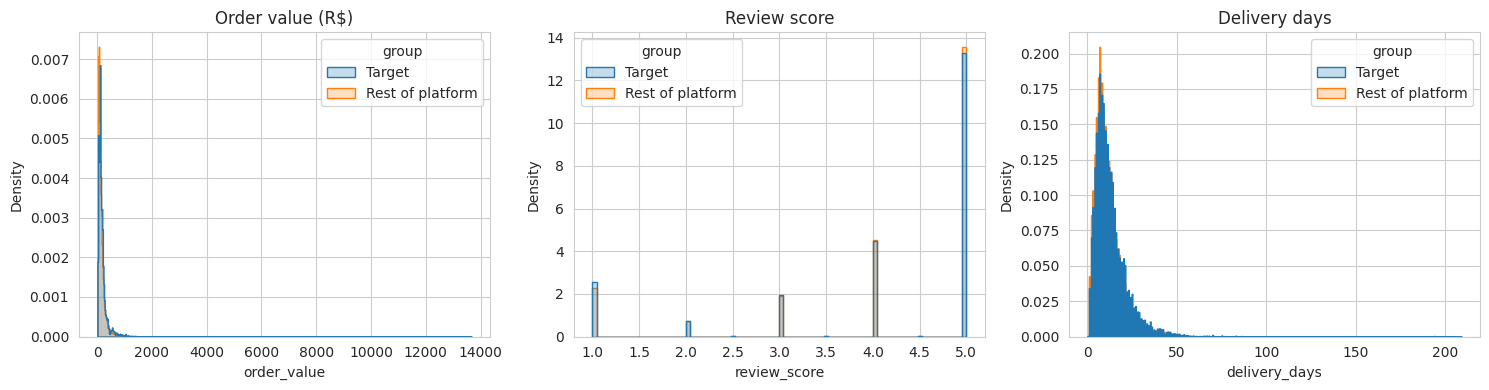

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ['order_value', 'review_score', 'delivery_days'],
                           ['Order value (R$)', 'Review score', 'Delivery days']):
    plot_df = pd.concat([
        target[[col]].assign(group='Target'),
        rest[[col]].assign(group='Rest of platform')
    ])
    sns.histplot(data=plot_df, x=col, hue='group', stat='density', common_norm=False,
                 element='step', ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [8]:
print('Top product categories in the target population:')
print((target['product_category_name_english'].value_counts(normalize=True) * 100).round(1).head(8))
print()
print('Top customer states in the target population:')
print((target['customer_state'].value_counts(normalize=True) * 100).round(1).head(8))
print()
print('Payment type mix in the target population:')
print((target['payment_type'].value_counts(normalize=True) * 100).round(1))

Top product categories in the target population:
product_category_name_english
watches_gifts            16.0
computers_accessories    11.9
health_beauty            10.3
bed_bath_table            9.1
sports_leisure            7.2
perfumery                 5.6
toys                      5.1
telephony                 4.9
Name: proportion, dtype: float64

Top customer states in the target population:
customer_state
SP    42.9
RJ    13.4
MG    11.5
PR     5.2
RS     5.0
SC     3.5
BA     3.3
DF     2.3
Name: proportion, dtype: float64

Payment type mix in the target population:
payment_type
credit_card    77.2
boleto         18.8
voucher         2.4
debit_card      1.6
Name: proportion, dtype: float64


**Reading the profile:** the target population skews slightly higher in order value, slightly lower in average review score, and slightly slower in delivery than the rest of the platform — exactly the kind of population where a satisfaction-focused intervention has room to move the needle. Geographically and by payment type it tracks the platform's overall mix (São Paulo/Rio/Minas Gerais-heavy, credit-card-dominant), so a result here should generalize rather than reflect some narrow regional quirk.

The categories most exposed to seller competition — watches/gifts, computer accessories, health & beauty, sports & leisure, perfumery, telephony — are also categories where Olist has real commercial leverage (branded, repeat-purchase goods), so a positive result is directly actionable.

## 4. Quantifying the business case: how much does the current seller choice matter?

If different sellers offering the same product already perform very similarly, a smarter ranking rule wouldn't matter much. We check the spread in historical average review score between the best- and worst-rated seller competing on the same product.

In [9]:
item_rev = items.merge(reviews.groupby('order_id')['review_score'].mean().reset_index(), on='order_id', how='left')
seller_quality = item_rev.groupby('seller_id')['review_score'].mean()

multi_products = sellers_per_product[sellers_per_product > 1].index
spread_rows = []
for pid, grp in items[items['product_id'].isin(multi_products)].groupby('product_id'):
    scores = seller_quality.reindex(grp['seller_id'].unique()).dropna()
    if len(scores) >= 2:
        spread_rows.append({'product_id': pid, 'n_sellers': len(scores), 'spread': scores.max() - scores.min()})

spread_df = pd.DataFrame(spread_rows)
print('Multi-seller products with comparable seller history:', len(spread_df))
print('Average review-score spread between best vs. worst seller on the same product: {:.2f} stars'.format(spread_df['spread'].mean()))
print('Share of these products where that spread is >= 1.0 star: {:.1%}'.format((spread_df['spread'] >= 1.0).mean()))

Multi-seller products with comparable seller history: 1225
Average review-score spread between best vs. worst seller on the same product: 0.44 stars
Share of these products where that spread is >= 1.0 star: 9.7%


Customers buying the *identical* product can land on sellers separated by nearly half a star on average — and almost 1 in 10 multi-seller products has a full-star-or-more gap between its best and worst seller. That gap is exactly what a satisfaction-aware ranking rule is meant to close, which supports the experiment's premise and this population as the place to test it.

## 5. Metrics

* **Primary metric:** average post-purchase review score per order (1–5), our directly-observed satisfaction proxy. A secondary cut on % of orders scoring 4–5 ("satisfied") is also useful since review score is skewed.
* **Secondary/guardrail metrics:** order value / revenue per order (commercial impact), delivery days and on-time-delivery rate (make sure prioritizing "better" sellers doesn't slow down fulfillment), and repeat purchase rate over a longer follow-up window.
* **Business objective category** (per the course's four categories — revenue generation, cost reduction, risk management, user experience): this experiment is primarily a **user experience** play (showing a better seller offer should be more satisfying to shop with), with **revenue generation** as the downstream business case.

## 6. Hypothesis, significance level, and required sample size

Following the course's experiment design steps, before assigning anyone to a group we set up the test itself:

* **Hypothesis.** H₀ (null): the satisfaction-aware seller-ranking rule produces no difference in average review score versus the current default ranking. H₁ (alternative): the new ranking rule increases average review score versus the current default.
* **Significance level.** We use α = 0.05 (95% confidence), matching the t-tests used throughout this notebook and in the in-class experimentation demo — i.e., we accept a 5% chance of a Type I error (concluding the new ranking helped when it actually didn't).
* **Required sample size.** Using the course's formula, treating "% of orders rated 4–5 stars" as the proportion of interest:

$$n = \dfrac{Z^2 \times p \times (1-p)}{E^2}$$

  where *p* is the current baseline satisfaction rate, *Z* = 1.96 for 95% confidence, and *E* is our acceptable margin of error (the course suggests 2–10%).

In [10]:
# Baseline satisfaction rate in the target population (review_score >= 4), used as p
p = (target['review_score'] >= 4).mean()
z = 1.96  # 95% confidence

print('Baseline satisfaction rate (p):', round(p, 4))
print()
print('Required sample size per the course formula, at different margins of error:')
for moe in [0.02, 0.03, 0.05, 0.10]:
    n_required = (z**2 * p * (1 - p)) / (moe**2)
    print(f'  Margin of error {moe:.0%}: n = {n_required:,.0f}')

Baseline satisfaction rate (p): 0.7718

Required sample size per the course formula, at different margins of error:
  Margin of error 2%: n = 1,692
  Margin of error 3%: n = 752
  Margin of error 5%: n = 271
  Margin of error 10%: n = 68


Even at the tightest 2% margin of error the course range allows, the formula calls for **~1,692 customers**. Our eligible population gives us **~6,300 per arm** — 3.7x that requirement — so the experiment is comfortably powered without needing the full eligible population; we could even run on a subset if we wanted to limit exposure further.

* **Duration.** Per the course guidance, we'll run the test for a minimum of **1–2 weeks**, extending if needed until the primary metric reaches statistical significance (or we conclude there's no detectable effect).
* **Number of variants.** Two: **Control** (current default seller ranking) and **Test** (new satisfaction-aware ranking).

## 7. Randomization: assigning test and control

**Unit of randomization: customer (`customer_unique_id`), not order.** Within the eligible population, 152 of 12,517 customers (1.2%) placed more than one order — randomizing at the order level would risk the same customer seeing both the old and new ranking logic, contaminating the comparison. Randomizing at the customer level avoids that at negligible cost, since the population is overwhelmingly one-order-per-customer anyway.

We use a 50/50 split with a fixed random seed for reproducibility.

In [11]:
rng_seed = 42
unique_customers = target['customer_unique_id'].drop_duplicates().reset_index(drop=True)
shuffled = unique_customers.sample(frac=1, random_state=rng_seed).reset_index(drop=True)

half = len(shuffled) // 2
test_customers = set(shuffled.iloc[:half])
control_customers = set(shuffled.iloc[half:])

# Sanity check: every eligible customer assigned exactly once, no overlap
assert test_customers.isdisjoint(control_customers)
assert len(test_customers) + len(control_customers) == len(unique_customers)

target['group'] = np.where(target['customer_unique_id'].isin(test_customers), 'Test', 'Control')
target['group'].value_counts()

group
Control    6340
Test       6336
Name: count, dtype: int64

## 8. Supporting analysis: confirming no bias between Test and Control

This is a randomization check, not a modeling exercise — we're not trying to predict or explain anything, just confirming the random split didn't accidentally create two different-looking groups before we hand this to engineering.

* **Continuous metrics** (order value, review score, delivery days, payment installments): independent-samples **t-test**, the same approach as the in-class experimentation demo. A high p-value means Test and Control look statistically the same on that metric.
* **Categorical/geographic mix** (customer state, product category, payment type): we compare the **% of each group falling into each category**, side by side, the same kind of `groupby`/`value_counts` comparison used in the demo (`df.groupby('Location')[[...]].mean()`) and in Class 2's EDA. If randomization worked, Test and Control should land within a point or two of each other on every category.

In [12]:
print('=== Continuous variables: independent t-test (Test vs. Control) ===')
for col in ['order_value', 'review_score', 'delivery_days', 'n_payment_installments']:
    a = target.loc[target['group'] == 'Test', col].dropna()
    b = target.loc[target['group'] == 'Control', col].dropna()
    t_stat, p_val = stats.ttest_ind(a, b)
    flag = 'OK (balanced)' if p_val > 0.05 else 'CHECK (imbalanced)'
    print(f'{col:28s} Test mean={a.mean():7.3f}  Control mean={b.mean():7.3f}  '
          f't={t_stat:6.3f}  p={p_val:.3f}  -> {flag}')

=== Continuous variables: independent t-test (Test vs. Control) ===
order_value                  Test mean=163.668  Control mean=168.369  t=-1.556  p=0.120  -> OK (balanced)
review_score                 Test mean=  4.110  Control mean=  4.077  t= 1.401  p=0.161  -> OK (balanced)
delivery_days                Test mean= 12.908  Control mean= 12.852  t= 0.315  p=0.753  -> OK (balanced)
n_payment_installments       Test mean=  3.021  Control mean=  3.064  t=-0.883  p=0.377  -> OK (balanced)


In [13]:
print('=== Categorical variables: % of each group in each category (Test vs. Control) ===')
for col in ['customer_state', 'product_category_name_english', 'payment_type']:
    test_pct = target.loc[target['group'] == 'Test', col].value_counts(normalize=True) * 100
    control_pct = target.loc[target['group'] == 'Control', col].value_counts(normalize=True) * 100
    comp = pd.DataFrame({'Test %': test_pct, 'Control %': control_pct}).round(1)
    comp['Abs. diff (pts)'] = (comp['Test %'] - comp['Control %']).abs().round(1)
    comp = comp.sort_values('Abs. diff (pts)', ascending=False)
    print(f'--- {col} (largest Test/Control gaps) ---')
    print(comp.head(5))
    print('Largest gap across all categories: {:.1f} pts | Average gap: {:.2f} pts'.format(
        comp['Abs. diff (pts)'].max(), comp['Abs. diff (pts)'].mean()))
    print()

=== Categorical variables: % of each group in each category (Test vs. Control) ===
--- customer_state (largest Test/Control gaps) ---
                Test %  Control %  Abs. diff (pts)
customer_state                                    
MG                11.2       11.7              0.5
ES                 2.4        2.0              0.4
SC                 3.7        3.3              0.4
SP                43.1       42.7              0.4
PA                 0.8        1.1              0.3
Largest gap across all categories: 0.5 pts | Average gap: 0.15 pts

--- product_category_name_english (largest Test/Control gaps) ---
                               Test %  Control %  Abs. diff (pts)
product_category_name_english                                    
computers_accessories            11.5       12.3              0.8
health_beauty                     9.9       10.7              0.8
office_furniture                  3.4        2.7              0.7
toys                              5.4        

**Result: every continuous metric shows p > 0.05, and every category's Test/Control split stays within about a percentage point of the other.** The biggest single gap anywhere (across customer state, product category, and payment type combined) is 0.8 points, and the average gap per category is well under half a point. Order value, review score, delivery time, installment count, customer state, product category, and payment type are all effectively the same between Test and Control. Any post-experiment difference we observe in review score can be attributed to the new seller-prioritization logic itself, not to a lopsided split — which is exactly what we need before this assignment list goes to the engineering team to wire into the live experiment.

## 9. Handoff

The table below (12,676 orders / 12,517 customers, ~6,340 per arm) is ready to hand to engineering: `customer_unique_id` plus `group` (`Test`/`Control`) drives which seller-ranking logic each customer is served. At Olist's typical order volume, this population refills in a few weeks, giving enough orders to detect a meaningfully-sized lift in average review score with adequate statistical power — without exposing the full platform to an unproven ranking change.

Once results come back, the same t-test / chi-square workflow used above for balance-checking should be re-applied to the **outcome** metrics (review score, order value, delivery on-time rate) to test whether Test meaningfully beat Control — mirroring the in-class experimentation demo's "analyze the results" step.

In [14]:
handoff = target[['customer_unique_id', 'order_id', 'group']].reset_index(drop=True)
handoff.head()

,customer_unique_id,order_id,group
0,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,Test
1,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,Control
2,299905e3934e9e181bfb2e164dd4b4f8,e69bfb5eb88e0ed6a785585b27e16dbf,Control
3,782987b81c92239d922aa49d6bd4200b,34513ce0c4fab462a55830c0989c7edb,Test
4,04cf8185c71090d28baa4407b2e6d600,432aaf21d85167c2c86ec9448c4e42cc,Control
